house price prediction
----------------------------------------
r2 score: 0.999
rmse: Rs. 59513.0
----------------------------------------
feature impact:
age_years       -81642.0
distance_km     -68182.0
floor             4687.0
bathrooms       123842.0
bedrooms        278646.0
area_sqft      2026705.0
dtype: float64


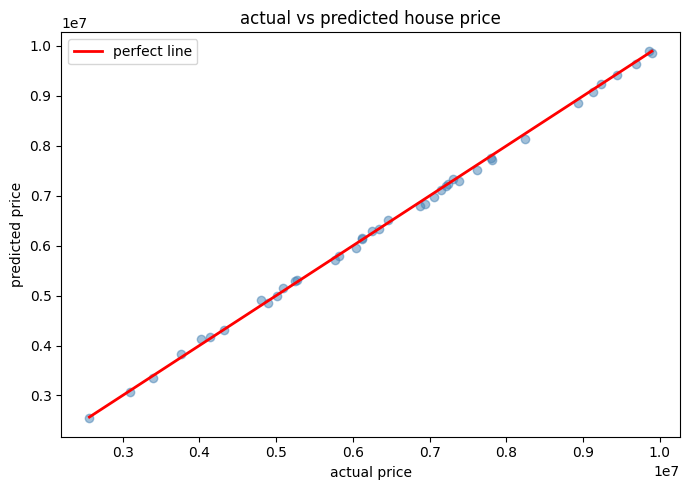

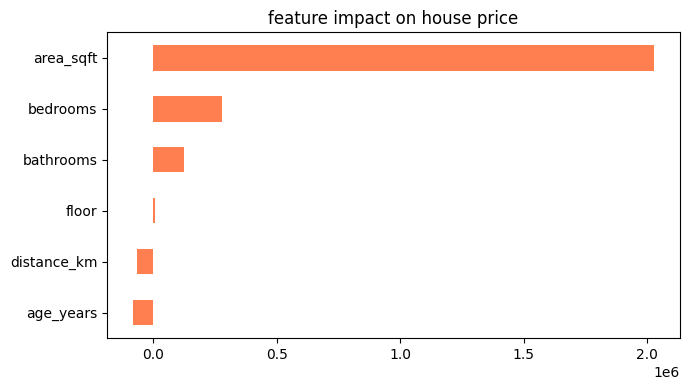

predicted price: Rs. 5720414.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [5]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 200

data = {
    "area_sqft":   np.random.randint(500, 3000, n),
    "bedrooms":    np.random.randint(1, 6, n),
    "bathrooms":   np.random.randint(1, 4, n),
    "floor":       np.random.randint(1, 20, n),
    "age_years":   np.random.randint(0, 30, n),
    "distance_km": np.random.randint(1, 50, n)
}

df = pd.DataFrame(data)

df["price"] = (df["area_sqft"] * 3000 +
               df["bedrooms"] * 200000 +
               df["bathrooms"] * 150000 -
               df["age_years"] * 10000 -
               df["distance_km"] * 5000 +
               np.random.randint(-100000, 100000, n) + 500000)

x = df.drop("price", axis=1)
y = df["price"]

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

model = Ridge(alpha=1.0)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("house price prediction")
print("-" * 40)
print("r2 score:", round(r2_score(y_test, y_pred), 3))
print("rmse: Rs.", round(np.sqrt(mean_squared_error(y_test, y_pred)), 0))
print("-" * 40)

coef = pd.Series(model.coef_, index=x.columns).sort_values()
print("feature impact:")
print(coef.round(0))

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color="steelblue")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linewidth=2, label="perfect line")
plt.title("actual vs predicted house price")
plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.legend()
plt.tight_layout()
plt.show()

coef.plot(kind="barh", color="coral", figsize=(7, 4))
plt.title("feature impact on house price")
plt.tight_layout()
plt.show()

new_house = scaler.transform([[1500, 3, 2, 5, 10, 15]])
pred_price = model.predict(new_house)
print("predicted price: Rs.", round(pred_price[0], 0))